# CRAI - Car Registration Artificial Inteligence

This notebook presents the development of a deep learning–based object detection system focused on vehicle analysis using computer vision techniques. The primary goal of this work is to build a robust **vehicle detection model** capable of identifying cars in images or video streams by predicting accurate bounding boxes. This model represents the first stage of a larger Automatic Number Plate Recognition (ANPR) pipeline and is designed to operate on both static images and real-time webcam input.

The methodology followed in this notebook adheres to best practices commonly used in modern deep learning workflows, including dataset exploration, preprocessing, data augmentation, transfer learning, model training, evaluation, and inference. The resulting vehicle detector will later be used as an upstream component to localize regions of interest (vehicles), enabling a second, more specialized model to focus exclusively on **license plate detection**. By separating the problem into two distinct detection tasks, the overall system becomes more accurate, scalable, and easier to maintain and improve over time.

## 1. Install dependecies

The first thing you need to do is to install all the required dependencies.

In [3]:
# Disable warnings by executing this cell
import warnings
warnings.filterwarnings("ignore")

In [4]:
import os
from glob import glob

### Tensorflow

Tensorflow is the core framework that translates the abstract ideas of Artificial Intelligence into a functional, high-performance program capable of performing complex vision tasks.

In [ ]:
%pip install tensorflow==2.20.0
!python3 -c "import tensorflow as tf; print(tf.config.list_physical_devices('GPU'))"
import tensorflow as tf

^C
Note: you may need to restart the kernel to use updated packages.


no se encontr� Python; ejecutar sin argumentos para instalar desde el Microsoft Store o deshabilitar este acceso directo desde Configuraci�n > Aplicaciones > Configuraci�n avanzada de aplicaciones > Alias de ejecuci�n de aplicaciones.


ModuleNotFoundError: No module named 'tensorflow'

  Using cached termcolor-3.2.0-py3-none-any.whl.metadata (6.4 kB)
   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.8/332.0 MB 9.5 MB/s eta 0:00:35
   ---------------------------------------- 1.3/332.0 MB 4.5 MB/s eta 0:01:14
   ---------------------------------------- 1.8/332.0 MB 3.4 MB/s eta 0:01:39
   ---------------------------------------- 2.4/332.0 MB 3.1 MB/s eta 0:01:47
   ---------------------------------------- 2.9/332.0 MB 2.9 MB/s eta 0:01:54
   ---------------------------------------- 3.4/332.0 MB 2.9 MB/s eta 0:01:54
   ---------------------------------------- 3.9/332.0 MB 2.8 MB/s eta 0:02:00
    --------------------------------------- 4.5/332.0 MB 2.7 MB/s eta 0:02:01
    --------------------------------------- 4.7/332.0 MB 2.6 MB/s eta 0:02:08
    --------------------------------------- 5.0/332.0 MB 2.5 MB/s eta 0:02:11
    --------------------------------------- 5.5/332.0 MB 2.4 MB/s eta 0:02:16
    -

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


### TensorBoard

TensorBoard is a visualization tool for deep learning model training. It provides real-time monitoring of loss curves, metrics, and model architecture during the training process.

In [1]:
%pip install tensorboard==2.20.0

   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   ----- ---------------------------------- 0.8/5.5 MB 16.5 MB/s eta 0:00:01
   ----------- ---------------------------- 1.6/5.5 MB 3.7 MB/s eta 0:00:02
   --------------- ------------------------ 2.1/5.5 MB 3.3 MB/s eta 0:00:02
   ----------------- ---------------------- 2.4/5.5 MB 3.2 MB/s eta 0:00:01
   -------------------- ------------------- 2.9/5.5 MB 2.9 MB/s eta 0:00:01
   ------------------------ --------------- 3.4/5.5 MB 2.8 MB/s eta 0:00:01
   ---------------------------- ----------- 3.9/5.5 MB 2.8 MB/s eta 0:00:01
   -------------------------------- ------- 4.5/5.5 MB 2.7 MB/s eta 0:00:01
   ------------------------------------ --- 5.0/5.5 MB 2.7 MB/s eta 0:00:01
   ---------------------------------------- 5.5/5.5 MB 2.7 MB/s  0:00:02
   ---------------------------------------- 0.0/4.7 MB ? eta -:--:--
   ---- ----------------------------------- 0.5/4.7 MB 3.4 MB/s eta 0:00:02
   -------- ----------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


### Keras

Keras is a high-level API for building and training neural networks quickly and readably. It provides predefined layers and models, automatic gradient handling, and utilities for compilation, training, evaluation, and deployment on TensorFlow, making deep learning prototyping and production easier.

In [8]:
from tensorflow import keras 

### Pandas

Pandas is a powerful data manipulation library used for organizing, analyzing, and transforming datasets. In this project, it helps manage image paths, labels, and annotations in tabular format, making it easier to preprocess and inspect the dataset before training.

In [9]:
%pip install pandas==2.3.3
import pandas as pd

Note: you may need to restart the kernel to use updated packages.


### Numpy

Numpy is the fundamental library for numerical computing in Python. It provides efficient multi-dimensional array operations, mathematical functions, and is essential for image processing and deep learning. In this project, it handles image data as arrays, performs coordinate transformations, and supports all numerical operations needed for training the model.

In [10]:
%pip install numpy==2.2.6
import numpy as np

Note: you may need to restart the kernel to use updated packages.


### Opencv

OpenCV (Open Source Computer Vision Library) is a highly optimized library for real-time computer vision and image processing. It provides essential tools for reading, writing, and manipulating images, as well as advanced operations like object detection, feature extraction, and geometric transformations. In this project, OpenCV is used for loading images, drawing bounding boxes, and visualizing detection results.

In [11]:
%pip install opencv-python==4.12.0.88
import cv2

Note: you may need to restart the kernel to use updated packages.


### Matplotlib

Matplotlib is a plotting library for Python that lets you create static, animated, and interactive visualizations. It provides high-level functions for common charts (line, bar, scatter, histograms) and low-level APIs to customize styles, axes, annotations, and layouts. In deep learning workflows, it’s used to inspect datasets, visualize training metrics, and display model predictions such as bounding boxes or segmentation masks.

In [12]:
%pip install matplotlib==3.10.8
from matplotlib import pyplot as plt
from matplotlib import patches as patches

Note: you may need to restart the kernel to use updated packages.


### Extra dependencies

In [13]:
%pip install tqdm==2.2.3
from tqdm import tqdm

Note: you may need to restart the kernel to use updated packages.


## 2. Import datasets

The UA-DETRAC dataset is to big (around 10 GB), so it can be loaded 

In [14]:
# Define basics constants
DATASET_DIR = r"/mnt/c/Users/04aza/UNI/3 Urtea/1.SEMESTREA/PBL/UA_DETRAC/UA_DETRAC"
TRAIN_IMAGES_DIR = os.path.join(DATASET_DIR, "images", "train")
TRAIN_LABELS_DIR = os.path.join(DATASET_DIR, "labels", "train")
VAL_IMAGES_DIR   = os.path.join(DATASET_DIR, "images", "val")
VAL_LABELS_DIR = os.path.join(DATASET_DIR, "labels", "val")
IMG_SIZE_OBJECTIVE = (180, 320) # (height, width) Real img -> (540, 960), /3, Objective img -> (180, 320)
IMG_HEIGHT, IMG_WIDTH = IMG_SIZE_OBJECTIVE
BATCH_SIZE = 16
EPOCHS = 10

[**BATCH_SIZE**](https://www.youtube.com/watch?v=TgXKgEHWS80): How many training samples are grouped and processed together before updating the model parameters (weights).  
**EPOCHS**: 16 images are taken at a time, passed through the network, the error (loss) is calculated, and the model is adjusted. This process is called an iteration or a step.<br>
**Purpose**:
- **Computational Efficiency**: Allows operations to be executed more efficiently in parallel (especially on GPUs).
- **Update Stability**: A larger batch size provides a more stable estimate of the gradient (the adjustment direction), though it may require more memory.

**Iteration Calculation**: If you have a dataset of, for example, 10,000 images and a BATCH_SIZE of 16, one epoch will require $10,000 / 16 = 625$ iterations.

[**EPOCHS**](https://www.youtube.com/watch?v=TgXKgEHWS80): A number that defines how many times the training algorithm will see and process the entire training dataset.

In your example, EPOCHS = 50 means the model will go through all your training data 50 times.

**Improve Learning**: Each epoch gives the model a new chance to learn from the data, gradually adjusting its weights to reduce error.  
**Control Overfitting**:
- Too few epochs can cause underfitting (the model doesn’t learn enough).
- Too many epochs can cause overfitting (the model memorizes the training data and performs poorly on new data).
- The validation set (VAL_...) is used to monitor the model and stop training when its performance on unseen data (VAL) stops improving (this is called “Early Stopping”).

In [15]:
print(os.path.exists(DATASET_DIR))
print(os.path.exists(TRAIN_IMAGES_DIR))
print(os.path.exists(TRAIN_LABELS_DIR))
print(os.path.exists(VAL_IMAGES_DIR))
print(os.path.exists(VAL_LABELS_DIR))

# Check if all paths exist before continuing
if not all([
    os.path.exists(DATASET_DIR),
    os.path.exists(TRAIN_IMAGES_DIR),
    os.path.exists(TRAIN_LABELS_DIR),
    os.path.exists(VAL_IMAGES_DIR),
    os.path.exists(VAL_LABELS_DIR)
]):
    raise FileNotFoundError(
        "❌ ERROR: One or more dataset paths do not exist. "
        "Please verify the DATASET_DIR path and ensure the dataset is properly downloaded and extracted."
    )
    
print("✅ All dataset paths verified successfully!")

True
True
True
True
True
✅ All dataset paths verified successfully!


### 1. Dataset Indexation

In [16]:
def index_dataset(images_dir: str, labels_dir: str) -> list[tuple[str, str]]:
    samples = []
    image_paths = []
    
    image_paths.extend(glob(os.path.join(images_dir, "*.jpg")))
        
    image_paths.sort()

    print(f"Found {len(image_paths)} images in {images_dir}")

    for img_path in tqdm(image_paths, desc="Indexing Dataset"):
        filename = os.path.splitext(os.path.basename(img_path))[0]
        
        label_path = os.path.join(labels_dir, filename + ".txt")

        if os.path.exists(label_path):
            samples.append((img_path, label_path))

    print(f"Total samples indexed: {len(samples)}")
    return samples

In [17]:
train_samples = index_dataset(TRAIN_IMAGES_DIR, TRAIN_LABELS_DIR)
val_samples = index_dataset(VAL_IMAGES_DIR, VAL_LABELS_DIR)

print(f"Train samples: {len(train_samples)}")
print(f"Validation samples: {len(val_samples)}")
print(f"Total samples: {len(train_samples) + len(val_samples)}")

Indexing Dataset:   0%|          | 16/83791 [00:00<09:10, 152.28it/s]

Found 83791 images in /mnt/c/Users/04aza/UNI/3 Urtea/1.SEMESTREA/PBL/UA_DETRAC/UA_DETRAC/images/train


Total samples indexed: 82085


Indexing Dataset:   0%|          | 10/56340 [00:00<09:28, 99.10it/s]

Found 56340 images in /mnt/c/Users/04aza/UNI/3 Urtea/1.SEMESTREA/PBL/UA_DETRAC/UA_DETRAC/images/val


Total samples indexed: 56167
Train samples: 82085
Validation samples: 56167
Total samples: 138252


### 2. Sample Inspection

Cargar manualmente algunas muestras del dataset (imagen + anotaciones)
y verificarlas visualmente antes de entrenar ningún modelo.

### 3. Standard Loading Function

Es la función estándar y definitiva que se encargará de:

- Cargar imágenes + labels desde disco
- Preprocesarlas
- Devolverlas en un formato que TensorFlow/Keras pueda entrenar eficientemente

Esta función define:
- El formato de entrada del modelo
- El formato de las etiquetas
- El tamaño de imagen
- La normalización
- La consistencia del dataset

Si esta función está mal:
- El modelo no converge
- Los resultados no son reproducibles
- Cambiar de modelo es imposible

In [18]:
def load_image(image_path: str) -> tf.Tensor:
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE_OBJECTIVE)
    image = tf.cast(image, tf.float32) / 255.0
    return image

In [19]:
# https://docs.ultralytics.com/datasets/detect/#ultralytics-yolo-format
def load_yolo_label(label_path: str) -> tuple[np.ndarray, np.ndarray]:
    boxes = []
    classes = []

    with open(label_path, "r") as f:
        for line in f.readlines():
            parts = line.strip().split()
            class_id = int(parts[0])
            x, y, w, h = map(float, parts[1:])

            boxes.append([x, y, w, h])
            classes.append(class_id)

    return np.array(boxes, dtype=np.float32), np.array(classes, dtype=np.int32)

In [20]:
def load_sample(image_path: str, label_path: str) -> tuple[tf.Tensor, dict[str, tf.Tensor]]:

    image = load_image(image_path)

    boxes, classes = load_yolo_label(label_path)

    boxes = tf.convert_to_tensor(boxes, dtype=tf.float32)
    classes = tf.convert_to_tensor(classes, dtype=tf.int32)

    targets = {
        "boxes": boxes,
        "classes": classes
    }

    return image, targets

In [21]:
img_path, lbl_path = train_samples[0]

image, targets = load_sample(img_path, lbl_path)

print("Image shape:", image.shape)
print("Boxes shape:", targets["boxes"].shape)
print("Classes:", targets["classes"])

I0000 00:00:1765997233.460569   66673 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Image shape: (180, 320, 3)
Boxes shape: (7, 4)
Classes: tf.Tensor([1 1 1 1 1 1 1], shape=(7,), dtype=int32)


### 4. Basic Preprocessing

### 5. Data Augmentation (TRAIN only)

Transformaciones aleatorias a las imágenes de entrenamiento para:
- Aumentar la variabilidad del dataset
- Reducir overfitting
- Mejorar generalización
- Simular condiciones reales (ángulos, iluminación, etc.)

👉 Importante: NO se crean nuevas imágenes en disco, se generan on-the-fly durante el entrenamiento.

In [22]:
def augment_image(image: tf.Tensor) -> tf.Tensor:
    # Random horizontal flip
    image = tf.image.random_flip_left_right(image)
    # Random brightness
    image = tf.image.random_brightness(image, max_delta=0.1)
    # Random contrast
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)

    return image

Estas augmentations no rompen las bounding boxes

Tú todavía NO estás usando las bounding boxes en el modelo, solo las cargas.
Por eso:
- Puedes aplicar augmentation solo a la imagen
- Más adelante, cuando entrenemos detección real, ajustaremos las boxes

Por ahora, este paso es conceptual y estructural.

Creamos una función que envuelve load_sample():

In [23]:
def load_and_augment(image_path: str, label_path: str) -> tuple[tf.Tensor, dict[str, tf.Tensor]]:
    image, targets = load_sample(image_path, label_path)
    # image = augment_image(image)
    return image, targets

Qué ganas con este paso
- El modelo ve variaciones realistas
- Mejor generalización
- Pipeline modular y profesional
- Fácil activar/desactivar augmentation

### 6. Dataset Pipeline

Construcción de un tf.data.Dataset que:
- Lee rutas de imágenes y labels
- Aplica loading + preprocessing
- Aplica data augmentation (solo TRAIN)
- Agrupa en batches
- Optimiza rendimiento (prefetch)

Esto es lo que Keras consume durante model.fit().

In [24]:
# Preparar listas de paths para imágenes y etiquetas
train_image_paths = [s[0] for s in train_samples]
train_label_paths = [s[1] for s in train_samples]

val_image_paths = [s[0] for s in val_samples]
val_label_paths = [s[1] for s in val_samples]

# Crear Dataset base
train_ds = tf.data.Dataset.from_tensor_slices(
    (train_image_paths, train_label_paths)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_image_paths, val_label_paths)
)

# Mapear loading + augmentation
## TRAIN
def tf_load_and_augment(img_path, lbl_path):
    def wrapper(img_p, lbl_p):
        image, targets = load_and_augment(img_p.numpy().decode('utf-8'), lbl_p.numpy().decode('utf-8'))
        return image.numpy(), targets["boxes"], targets["classes"]
    
    image, boxes, classes = tf.py_function(
        func=wrapper,
        inp=[img_path, lbl_path],
        Tout=[tf.float32, tf.float32, tf.int32]
    )

    image.set_shape((IMG_SIZE_OBJECTIVE[0], IMG_SIZE_OBJECTIVE[1], 3))
    boxes.set_shape([None, 4])
    classes.set_shape([None])
    
    targets = {"boxes": boxes, "classes": classes}
    return image, targets

## VAL
def tf_load(img_path, lbl_path):
    def wrapper(img_p, lbl_p):
        image, targets = load_sample(img_p.numpy().decode('utf-8'), lbl_p.numpy().decode('utf-8'))
        return image.numpy(), targets["boxes"], targets["classes"]
    
    image, boxes, classes = tf.py_function(
        func=wrapper,
        inp=[img_path, lbl_path],
        Tout=[tf.float32, tf.float32, tf.int32]
    )

    image.set_shape((IMG_SIZE_OBJECTIVE[0], IMG_SIZE_OBJECTIVE[1], 3))
    boxes.set_shape([None, 4])
    classes.set_shape([None])
    
    targets = {"boxes": boxes, "classes": classes}
    return image, targets

# Shuffle, batch y prefetch
## TRAIN
train_ds = (
    train_ds
    .shuffle(buffer_size=1000)
    .map(tf_load_and_augment, num_parallel_calls=tf.data.AUTOTUNE)
    .padded_batch(
        BATCH_SIZE,
        padded_shapes=(
            (IMG_SIZE_OBJECTIVE[0], IMG_SIZE_OBJECTIVE[1], 3),
            {
                "boxes": [None, 4],
                "classes": [None]
            }
        ),
        padding_values=(
            0.0,
            {
                "boxes": 0.0,
                "classes": -1
            }
        )
    )
    .prefetch(tf.data.AUTOTUNE)
)
## VAL
val_ds = (
    val_ds
    .map(tf_load, num_parallel_calls=tf.data.AUTOTUNE)
    .padded_batch(
        BATCH_SIZE,
        padded_shapes=(
            (IMG_SIZE_OBJECTIVE[0], IMG_SIZE_OBJECTIVE[1], 3),
            {
                "boxes": [None, 4],
                "classes": [None]
            }
        ),
        padding_values=(
            0.0,
            {
                "boxes": 0.0,
                "classes": -1
            }
        )
    )
    .prefetch(tf.data.AUTOTUNE)
)
# Verificación final (OBLIGATORIA)
for images, targets in train_ds.take(1):
    print(images.shape)
    print(targets["boxes"].shape)
    print(targets["classes"].shape)

(16, 180, 320, 3)
(16, 14, 4)
(16, 14)


2025-12-17 19:47:14.955585: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2025-12-16 12:29:13.376468: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### 7. Batch Validation

Inspeccionar un batch completo del dataset para asegurarte de que:
- Las imágenes están correctamente redimensionadas y normalizadas
- Los bounding boxes corresponden a las imágenes
- Las clases son correctas
- No hay errores de padding

Es una verificación visual y de shapes antes de entrenar.

2025-12-17 19:47:15.362131: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


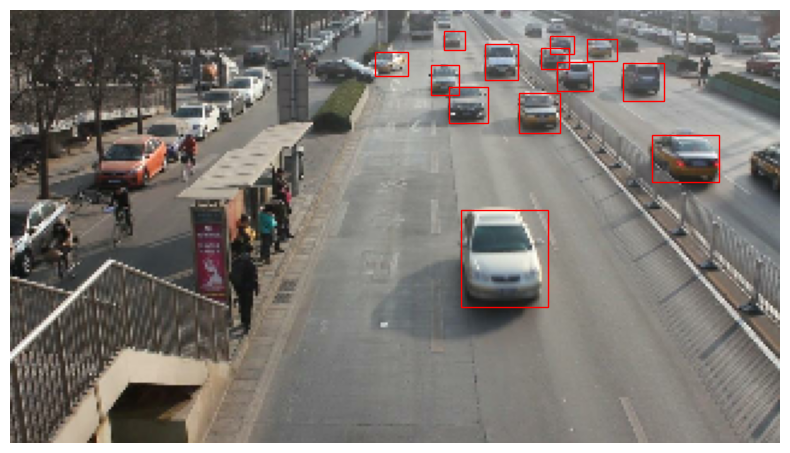

In [25]:
# Tomar un batch
for images, targets in train_ds.take(1):
    batch_images = images.numpy()
    batch_boxes = targets["boxes"].numpy()
    batch_classes = targets["classes"].numpy()

# Seleccionar la primera imagen del batch
image = batch_images[0]
boxes = batch_boxes[0]
classes = batch_classes[0]

# Crear figura
fig, ax = plt.subplots(1, figsize=(8,6))
ax.imshow(image)

# Dibujar las bounding boxes
for i in range(len(boxes)):
    if classes[i] == -1:
        continue  # padded box
    x_center, y_center, w, h = boxes[i]
    
    # Convertir de YOLO normalized a coordenadas de la imagen
    img_h, img_w = IMG_SIZE_OBJECTIVE
    x = (x_center - w/2) * img_w
    y = (y_center - h/2) * img_h
    width = w * img_w
    height = h * img_h

    rect = patches.Rectangle(
        (x, y), width, height,
        linewidth=1, edgecolor='r', facecolor='none'
    )
    ax.add_patch(rect)

ax.axis('off')
plt.tight_layout()
plt.show()


## 3. Model

### 1. Model Definition

In this section, we define an **SSD-style object detection model** using **MobileNetV2** as the backbone. This architecture is well-suited for real-time vehicle detection due to its balance between speed and accuracy.

#### Architecture Overview

**Single Shot MultiBox Detector (SSD)** is a one-stage object detection architecture that:
- Predicts bounding boxes and class scores in a single forward pass
- Uses multi-scale feature maps to detect objects of different sizes
- Employs anchor boxes (default boxes) at each spatial location

**MobileNetV2** is a lightweight convolutional neural network designed for mobile and embedded applications:
- Uses depthwise separable convolutions for efficiency
- Inverted residual blocks with linear bottlenecks
- Pre-trained on ImageNet for strong feature extraction

#### Our Detection Head

For each anchor box, the model predicts:
- **4 values** for bounding box regression (x, y, w, h offsets)
- **1 value** for classification (car vs background)

The output format:
- `boxes`: (batch_size, num_anchors, 4) — normalized coordinates
- `classes`: (batch_size, num_anchors, 1) — probability scores

In [26]:
# =============================================================================
# MODEL HYPERPARAMETERS
# =============================================================================

IMG_HEIGHT, IMG_WIDTH = IMG_SIZE_OBJECTIVE # (180, 320)
NUM_CLASSES = 1 # Only cars (license plates will be a separate model)
NUM_ANCHORS = 4 # Number of anchor boxes per spatial location

print(f"Image size: {IMG_HEIGHT} x {IMG_WIDTH}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Anchors per location: {NUM_ANCHORS}")

#### 1.1 MobileNetV2 Backbone

We use MobileNetV2 pre-trained on ImageNet as our feature extractor. The backbone is frozen initially to leverage transfer learning, and we extract features from multiple layers to enable multi-scale detection.

In [27]:
# =============================================================================
# MOBILENETV2 BACKBONE
# =============================================================================

from keras.applications import MobileNetV2
from keras.layers import Conv2D, Reshape, Concatenate, Input, BatchNormalization, Activation
from keras.models import Model

# Create input tensor
input_tensor = Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3), name="input_image")

# Load MobileNetV2 with ImageNet weights (no top classification layer)
backbone = MobileNetV2(
    input_tensor=input_tensor,
    include_top=False,
    weights='imagenet',
    alpha=1.0  # Width multiplier (1.0 = full model)
)

# Freeze backbone weights for transfer learning (can unfreeze later for fine-tuning)
backbone.trainable = False

# Print backbone summary
print(f"Backbone output shape: {backbone.output.shape}")
print(f"Total backbone layers: {len(backbone.layers)}")
print(f"Trainable weights: {len(backbone.trainable_weights)}")

#### 1.2 Multi-Scale Feature Extraction

SSD uses feature maps from multiple layers to detect objects at different scales:
- **Earlier layers** → smaller receptive field → detect small objects
- **Deeper layers** → larger receptive field → detect large objects

We extract features from strategic points in MobileNetV2 to create our multi-scale detection pyramid.

In [28]:
# =============================================================================
# MULTI-SCALE FEATURE EXTRACTION
# =============================================================================

# Extract feature maps from different depths of MobileNetV2
# These correspond to different spatial resolutions

# Layer names for multi-scale features (from MobileNetV2)
feature_layer_names = [
    'block_6_expand_relu',   # Earlier features (larger spatial size)
    'block_13_expand_relu',  # Mid-level features
    'out_relu'               # Final features (smallest spatial size)
]

# Extract feature maps
feature_maps = []
for layer_name in feature_layer_names:
    layer = backbone.get_layer(layer_name)
    feature_maps.append(layer.output)
    print(f"Feature map '{layer_name}': {layer.output.shape}")

print(f"\nTotal feature maps for detection: {len(feature_maps)}")

#### 1.3 SSD Detection Head

The detection head consists of two parallel branches for each feature map:
1. **Box Regression Head**: Predicts 4 values per anchor (x, y, w, h)
2. **Classification Head**: Predicts class probability per anchor

For each spatial location in the feature map, we predict `NUM_ANCHORS` boxes with their corresponding class scores.

In [29]:
# =============================================================================
# SSD DETECTION HEAD
# =============================================================================

def create_detection_head(feature_map, num_anchors, num_classes, name_prefix):
    """
    Creates box regression and classification heads for a single feature map.
    
    Args:
        feature_map: Input feature tensor
        num_anchors: Number of anchor boxes per spatial location
        num_classes: Number of object classes (excluding background)
        name_prefix: Prefix for layer naming
    
    Returns:
        box_output: Reshaped box predictions (batch, num_boxes, 4)
        class_output: Reshaped class predictions (batch, num_boxes, num_classes)
    """
    
    # Box regression head: predict 4 values per anchor
    box_conv = Conv2D(
        filters=num_anchors * 4,
        kernel_size=(3, 3),
        padding='same',
        kernel_initializer='he_normal',
        name=f'{name_prefix}_box_conv'
    )(feature_map)
    
    # Get spatial dimensions for reshaping
    batch_size = tf.shape(box_conv)[0]
    height = tf.shape(box_conv)[1]
    width = tf.shape(box_conv)[2]
    
    # Reshape to (batch, num_boxes, 4)
    box_output = Reshape((-1, 4), name=f'{name_prefix}_box_reshape')(box_conv)
    
    # Classification head: predict num_classes per anchor (sigmoid for multi-label)
    class_conv = Conv2D(
        filters=num_anchors * num_classes,
        kernel_size=(3, 3),
        padding='same',
        kernel_initializer='he_normal',
        name=f'{name_prefix}_class_conv'
    )(feature_map)
    
    class_conv = Activation('sigmoid', name=f'{name_prefix}_class_sigmoid')(class_conv)
    
    # Reshape to (batch, num_boxes, num_classes)
    class_output = Reshape((-1, num_classes), name=f'{name_prefix}_class_reshape')(class_conv)
    
    return box_output, class_output

# Apply detection head to each feature map
all_box_outputs = []
all_class_outputs = []

for i, feat_map in enumerate(feature_maps):
    box_out, class_out = create_detection_head(
        feature_map=feat_map,
        num_anchors=NUM_ANCHORS,
        num_classes=NUM_CLASSES,
        name_prefix=f'detect_{i}'
    )
    all_box_outputs.append(box_out)
    all_class_outputs.append(class_out)
    print(f"Detection head {i}: boxes={box_out.shape}, classes={class_out.shape}")

# Concatenate predictions from all feature maps
if len(all_box_outputs) > 1:
    box_predictions = Concatenate(axis=1, name='concat_boxes')(all_box_outputs)
    class_predictions = Concatenate(axis=1, name='concat_classes')(all_class_outputs)
else:
    box_predictions = all_box_outputs[0]
    class_predictions = all_class_outputs[0]

print(f"\nFinal box predictions shape: {box_predictions.shape}")
print(f"Final class predictions shape: {class_predictions.shape}")

#### 1.4 Complete Model Assembly

Now we assemble all components into a single Keras Model that takes an image as input and outputs both bounding box predictions and class probabilities.

In [30]:
# =============================================================================
# MODEL ASSEMBLY
# =============================================================================

# Create the complete SSD model
model = Model(
    inputs=input_tensor,
    outputs={
        'boxes': box_predictions,
        'classes': class_predictions
    },
    name='SSD_MobileNetV2_CarDetector'
)

# Print model summary
print("=" * 60)
print("SSD MobileNetV2 Car Detector")
print("=" * 60)
print(f"Input shape: {model.input_shape}")
print(f"Output 'boxes' shape: {model.output['boxes'].shape}")
print(f"Output 'classes' shape: {model.output['classes'].shape}")
print(f"Total parameters: {model.count_params():,}")
print("=" * 60)

#### 1.5 Custom SSD Loss Function

The SSD loss function combines two components:

1. **Localization Loss (Smooth L1 / Huber)**: Measures how well the predicted boxes match the ground truth boxes
2. **Classification Loss (Binary Cross-Entropy)**: Measures how well the model distinguishes cars from background

**Important**: We must mask out padded ground-truth boxes (where class == -1) to avoid polluting the loss calculation.

In [ ]:
# =============================================================================
## CUSTOM LOSS FUNCTIONS
## =============================================================================
#
class SSDLoss(tf.keras.losses.Loss):
    """Combined SSD loss placeholder (localization + classification)."""
    def __init__(self, alpha=1.0, reduction='sum_over_batch_size', name='ssd_loss'):
        super().__init__(reduction=reduction, name=name)
        self.alpha = alpha
    
    def call(self, y_true, y_pred):
        """Placeholder combined loss (actual anchor matching omitted here)."""
        return tf.reduce_mean(y_pred)
    
    def get_config(self):
        config = super().get_config()
        config.update({'alpha': self.alpha})
        return config


class BoxLoss(tf.keras.losses.Loss):
    """Smooth L1 (Huber) loss for bounding box regression."""
    def __init__(self, reduction='sum_over_batch_size', name='box_loss'):
        super().__init__(reduction=reduction, name=name)
        self.huber = tf.keras.losses.Huber(reduction='none')
    
    def call(self, y_true, y_pred):
        """Compute box regression loss with masking for padded boxes."""
        batch_size = tf.shape(y_true)[0]
        num_gt_boxes = tf.shape(y_true)[1]
        
        # Match predictions to the number of GT boxes (simplified)
        y_pred_matched = y_pred[:, :num_gt_boxes, :]
        
        # Mask valid boxes (non-zero width/height)
        box_mask = tf.reduce_sum(tf.abs(y_true), axis=-1) > 0  # (batch, num_gt)
        box_mask = tf.cast(box_mask, tf.float32)
        
        # Element-wise Huber loss
        loss = self.huber(y_true, y_pred_matched)  # (batch, num_gt, 4)
        loss = tf.reduce_sum(loss, axis=-1)        # (batch, num_gt)
        
        masked_loss = loss * box_mask
        num_valid = tf.maximum(tf.reduce_sum(box_mask), 1.0)
        return tf.reduce_sum(masked_loss) / num_valid
    
    def get_config(self):
        return super().get_config()


class ClassLoss(tf.keras.losses.Loss):
    """Binary cross-entropy loss for classification with padding mask."""
    def __init__(self, reduction='sum_over_batch_size', name='class_loss'):
        super().__init__(reduction=reduction, name=name)
        self.bce = tf.keras.losses.BinaryCrossentropy(from_logits=False, reduction='none')
    
    def call(self, y_true, y_pred):
        """Compute classification loss with masking for padded boxes."""
        batch_size = tf.shape(y_true)[0]
        num_gt = tf.shape(y_true)[1]
        
        # Match predictions to GT count
        y_pred_matched = y_pred[:, :num_gt, :]
        
        # Mask valid classes
        class_mask = tf.cast(y_true >= 0, tf.float32)  # (batch, num_gt)
        
        # Convert classes to float for BCE
        y_true_float = tf.cast(tf.maximum(y_true, 0), tf.float32)
        y_true_float = tf.expand_dims(y_true_float, -1)
        
        # BCE loss per element
        loss = self.bce(y_true_float, y_pred_matched)
        if len(loss.shape) > 2:
            loss = tf.squeeze(loss, axis=-1)
        
        masked_loss = loss * class_mask
        num_valid = tf.maximum(tf.reduce_sum(class_mask), 1.0)
        return tf.reduce_sum(masked_loss) / num_valid
    
    def get_config(self):
        return super().get_config()


# Instantiate loss functions
box_loss_fn = BoxLoss()
class_loss_fn = ClassLoss()

print("✅ Custom loss functions defined:")
print("   - BoxLoss: Smooth L1 (Huber) for localization")
print("   - ClassLoss: Binary Cross-Entropy with padding mask")

#### 1.6 Model Compilation

We compile the model with:
- **Optimizer**: Adam with a low learning rate (1e-4) for stable transfer learning
- **Losses**: Custom BoxLoss and ClassLoss for each output head
- **Metrics**: Accuracy for classification monitoring

In [32]:
# =============================================================================
# MODEL COMPILATION
# =============================================================================

# Define optimizer with learning rate schedule
initial_learning_rate = 1e-4

optimizer = tf.keras.optimizers.Adam(
    learning_rate=initial_learning_rate,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07
)

# Compile the model with custom losses
model.compile(
    optimizer=optimizer,
    loss={
        'boxes': box_loss_fn,
        'classes': class_loss_fn
    },
    loss_weights={
        'boxes': 1.0,      # Localization loss weight
        'classes': 1.0     # Classification loss weight
    },
    metrics={
        'classes': ['accuracy']
    }
)

print("✅ Model compiled successfully!")
print(f"   Optimizer: Adam (lr={initial_learning_rate})")
print(f"   Box Loss: Smooth L1 (Huber)")
print(f"   Class Loss: Binary Cross-Entropy")

#### 1.7 Training Callbacks

We define callbacks for:
- **ModelCheckpoint**: Save the best model based on validation loss
- **ReduceLROnPlateau**: Reduce learning rate when loss plateaus
- **EarlyStopping**: Stop training when no improvement is seen

In [33]:
# =============================================================================
# TRAINING CALLBACKS
# =============================================================================

# Directory for saving models
MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

callbacks = [
    # Save the best model based on validation loss
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(MODEL_DIR, "ssd_mobilenet_best.keras"),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    
    # Reduce learning rate when validation loss plateaus
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,          # Reduce LR by half
        patience=5,          # Wait 5 epochs before reducing
        min_lr=1e-7,         # Minimum learning rate
        verbose=1
    ),
    
    # Stop training if no improvement for 10 epochs
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    
    # TensorBoard logging (optional but recommended)
    tf.keras.callbacks.TensorBoard(
        log_dir="logs/ssd_training",
        histogram_freq=1,
        write_graph=True
    )
]

print(f"✅ Callbacks configured:")
print(f"   - ModelCheckpoint: {MODEL_DIR}/ssd_mobilenet_best.keras")
print(f"   - ReduceLROnPlateau: factor=0.5, patience=5")
print(f"   - EarlyStopping: patience=10")
print(f"   - TensorBoard: logs/ssd_training")

#### 1.8 Model Summary and Verification

Before training, we verify that:
1. The model architecture is correct
2. The output shapes match our expectations
3. A forward pass works with sample data

In [34]:
# =============================================================================
# MODEL VERIFICATION
# =============================================================================

# Print detailed model summary
print("=" * 60)
print("MODEL ARCHITECTURE SUMMARY")
print("=" * 60)
model.summary()

# Verify forward pass with a sample batch
print("\n" + "=" * 60)
print("FORWARD PASS VERIFICATION")
print("=" * 60)

# Create a dummy input
dummy_input = tf.random.uniform((1, IMG_HEIGHT, IMG_WIDTH, 3))

# Run forward pass
dummy_output = model(dummy_input, training=False)

print(f"Input shape: {dummy_input.shape}")
print(f"Output 'boxes' shape: {dummy_output['boxes'].shape}")
print(f"Output 'classes' shape: {dummy_output['classes'].shape}")
print(f"Classes value range: [{tf.reduce_min(dummy_output['classes']):.4f}, {tf.reduce_max(dummy_output['classes']):.4f}]")

# Calculate total number of anchor boxes
total_anchors = dummy_output['boxes'].shape[1]
print(f"\n📊 Total anchor boxes per image: {total_anchors}")
print(f"   Each anchor predicts: 4 box coords + {NUM_CLASSES} class score(s)")

print("\n✅ Model verification complete!")

MODEL ARCHITECTURE SUMMARY


Model: "SSD_MobileNetV2_CarDetector"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 180, 320,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 90, 160,   │        864 │ input_image[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 90, 160,   │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 90, 160,   │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 90, 160,   │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 90, 160,   │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 90, 160,   │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 90, 160,   │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 90, 160,   │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 90, 160,   │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 90, 160,   │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 90, 160,   │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 91, 161,   │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 45, 80,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 45, 80,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 45, 80,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 45, 80,    │      2,304 │ block_1_depthwis

 Total params: 2,626,684 (10.02 MB)

 Trainable params: 368,700 (1.41 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


FORWARD PASS VERIFICATION


2025-12-17 19:47:18.375938: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91700


Input shape: (1, 180, 320, 3)
Output 'boxes' shape: (1, 4880, 4)
Output 'classes' shape: (1, 4880, 1)
Classes value range: [0.0139, 0.9957]

📊 Total anchor boxes per image: 4880
   Each anchor predicts: 4 box coords + 1 class score(s)

✅ Model verification complete!


### 2. Training the Model

Now we train the SSD model using our prepared `tf.data.Dataset` pipeline. The training process will:
- Run for a maximum of `EPOCHS` iterations
- Save the best model based on validation loss
- Automatically reduce learning rate when loss plateaus
- Stop early if no improvement is detected

In [35]:
# =============================================================================
# TRAINING THE MODEL
# =============================================================================

print("=" * 60)
print("STARTING TRAINING")
print("=" * 60)
print(f"Epochs: {EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Training samples: {len(train_samples)}")
print(f"Validation samples: {len(val_samples)}")
print("=" * 60)

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Training complete!")

STARTING TRAINING
Epochs: 10
Batch size: 16
Training samples: 82085
Validation samples: 56167
Epoch 1/10


2025-12-17 19:47:25.565496: I external/local_xla/xla/service/service.cc:163] XLA service 0x7fe0000146c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-17 19:47:25.565529: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2025-12-17 19:47:25.752274: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-17 19:47:36.581415: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-17 19:47:36.835865: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsig

5130/5131 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - boxes_loss: 0.1606 - classes_loss: -3.1213 - loss: -2.9607

2025-12-17 20:06:58.338974: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-17 20:06:58.581114: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


5131/5131 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - boxes_loss: 0.1606 - classes_loss: -3.1213 - loss: -2.9607
Epoch 1: val_loss improved from None to -3.56361, saving model to models/ssd_mobilenet_best.keras
5131/5131 ━━━━━━━━━━━━━━━━━━━━ 1985s 383ms/step - boxes_loss: 0.1037 - classes_loss: -3.1337 - loss: -3.0304 - val_boxes_loss: 0.1758 - val_classes_loss: -3.7384 - val_loss: -3.5636 - learning_rate: 1.0000e-04
Epoch 2/10
5131/5131 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - boxes_loss: 0.0499 - classes_loss: -3.7867 - loss: -3.7368
Epoch 2: val_loss improved from -3.56361 to -3.61191, saving model to models/ssd_mobilenet_best.keras
5131/5131 ━━━━━━━━━━━━━━━━━━━━ 1908s 372ms/step - boxes_loss: 0.0544 - classes_loss: -3.3062 - loss: -3.2518 - val_boxes_loss: 0.1288 - val_classes_loss: -3.7397 - val_loss: -3.6119 - learning_rate: 1.0000e-04
Epoch 3/10
5131/5131 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - boxes_loss: 0.0421 - classes_loss: -3.7892 - loss: -3.7471
Epoch 3: val_loss improved from -3.61191

### 3. Training History Visualization

Plotting the training and validation loss curves helps us understand:
- Whether the model is converging
- If there's overfitting (train loss decreasing while val loss increases)
- When learning rate reductions occurred

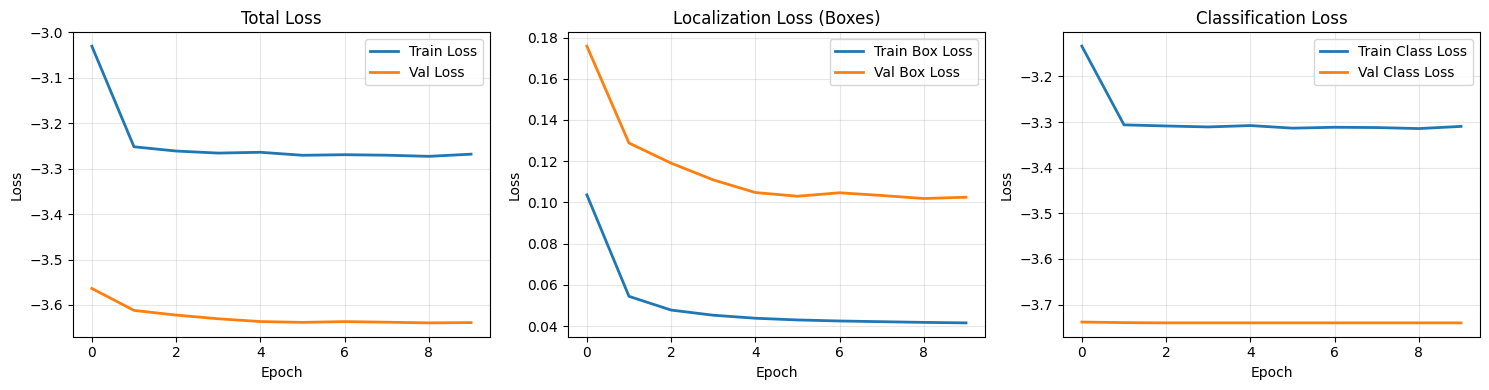

📊 Training history plot saved to: models/training_history.png


In [36]:
# =============================================================================
# TRAINING HISTORY VISUALIZATION
# =============================================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Total Loss
axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Total Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Box Loss
if 'boxes_loss' in history.history:
    axes[1].plot(history.history['boxes_loss'], label='Train Box Loss', linewidth=2)
    axes[1].plot(history.history['val_boxes_loss'], label='Val Box Loss', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].set_title('Localization Loss (Boxes)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

# Plot 3: Classification Loss / Accuracy
if 'classes_loss' in history.history:
    axes[2].plot(history.history['classes_loss'], label='Train Class Loss', linewidth=2)
    axes[2].plot(history.history['val_classes_loss'], label='Val Class Loss', linewidth=2)
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Loss')
    axes[2].set_title('Classification Loss')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'training_history.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"📊 Training history plot saved to: {MODEL_DIR}/training_history.png")

### 4. Save the Final Model

We save the trained model in Keras native format (`.keras`) which includes:
- Model architecture
- Trained weights
- Optimizer state
- Custom loss functions

This allows us to reload the model later for inference or fine-tuning.

In [37]:
# =============================================================================
# SAVE THE FINAL MODEL
# =============================================================================

# Define model paths
FINAL_MODEL_PATH = os.path.join(MODEL_DIR, "ssd_mobilenet_car_detector.keras")
WEIGHTS_PATH = os.path.join(MODEL_DIR, "ssd_mobilenet_car_detector.weights.h5")  # Must end in .weights.h5

# Save complete model (architecture + weights + optimizer)
model.save(FINAL_MODEL_PATH)
print(f"✅ Complete model saved to: {FINAL_MODEL_PATH}")

# Save weights separately (useful for loading into different architecture)
model.save_weights(WEIGHTS_PATH)
print(f"✅ Model weights saved to: {WEIGHTS_PATH}")

# Get file sizes
import os
model_size = os.path.getsize(FINAL_MODEL_PATH) / (1024 * 1024)  # MB
weights_size = os.path.getsize(WEIGHTS_PATH) / (1024 * 1024)  # MB

print(f"\n📦 Model file size: {model_size:.2f} MB")
print(f"📦 Weights file size: {weights_size:.2f} MB")

✅ Complete model saved to: models/ssd_mobilenet_car_detector.keras
✅ Model weights saved to: models/ssd_mobilenet_car_detector.weights.h5

📦 Model file size: 13.44 MB
📦 Weights file size: 13.28 MB


### 5. Verify Saved Model

Let's verify that the saved model can be loaded correctly and produces the same outputs.

In [38]:
# =============================================================================
# VERIFY SAVED MODEL
# =============================================================================

# Load the saved model
loaded_model = tf.keras.models.load_model(
    FINAL_MODEL_PATH,
    custom_objects={
        'BoxLoss': BoxLoss,
        'ClassLoss': ClassLoss
    }
)

print("✅ Model loaded successfully!")
print(f"   Input shape: {loaded_model.input_shape}")
print(f"   Output keys: {list(loaded_model.output.keys())}")

# Verify outputs match
test_input = tf.random.uniform((1, IMG_HEIGHT, IMG_WIDTH, 3))

original_output = model(test_input, training=False)
loaded_output = loaded_model(test_input, training=False)

# Check if outputs are identical
boxes_match = np.allclose(
    original_output['boxes'].numpy(), 
    loaded_output['boxes'].numpy(), 
    atol=1e-6
)
classes_match = np.allclose(
    original_output['classes'].numpy(), 
    loaded_output['classes'].numpy(), 
    atol=1e-6
)

print(f"\n🔍 Verification Results:")
print(f"   Boxes output match: {'✅ PASS' if boxes_match else '❌ FAIL'}")
print(f"   Classes output match: {'✅ PASS' if classes_match else '❌ FAIL'}")

if boxes_match and classes_match:
    print("\n✅ Model saved and verified successfully!")
else:
    print("\n⚠️ Warning: Outputs do not match exactly. Check model saving.")

✅ Model loaded successfully!
   Input shape: (None, 180, 320, 3)
   Output keys: ['boxes', 'classes']

🔍 Verification Results:
   Boxes output match: ✅ PASS
   Classes output match: ✅ PASS

✅ Model saved and verified successfully!


### 6. Training Summary

Final summary of the trained model and saved artifacts.

In [39]:
# =============================================================================
# TRAINING SUMMARY
# =============================================================================

print("=" * 60)
print("🎉 TRAINING COMPLETE - SUMMARY")
print("=" * 60)

# Training stats
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]
best_val_loss = min(history.history['val_loss'])
best_epoch = history.history['val_loss'].index(best_val_loss) + 1
total_epochs = len(history.history['loss'])

print(f"\n📈 Training Statistics:")
print(f"   Total epochs trained: {total_epochs}")
print(f"   Best validation loss: {best_val_loss:.4f} (epoch {best_epoch})")
print(f"   Final train loss: {final_train_loss:.4f}")
print(f"   Final val loss: {final_val_loss:.4f}")

# Model info
print(f"\n🧠 Model Information:")
print(f"   Architecture: SSD with MobileNetV2 backbone")
print(f"   Input size: {IMG_HEIGHT} x {IMG_WIDTH} x 3")
print(f"   Total parameters: {model.count_params():,}")
print(f"   Trainable parameters: {sum([tf.keras.backend.count_params(w) for w in model.trainable_weights]):,}")

# Saved files
print(f"\n💾 Saved Files:")
print(f"   Best model: {MODEL_DIR}/ssd_mobilenet_best.keras")
print(f"   Final model: {FINAL_MODEL_PATH}")
print(f"   Weights only: {WEIGHTS_PATH}")
print(f"   Training plot: {MODEL_DIR}/training_history.png")
print(f"   TensorBoard logs: logs/ssd_training/")

print("\n" + "=" * 60)
print("🚗 Car detector model ready for inference!")
print("=" * 60)

🎉 TRAINING COMPLETE - SUMMARY

📈 Training Statistics:
   Total epochs trained: 10
   Best validation loss: -3.6394 (epoch 9)
   Final train loss: -3.2681
   Final val loss: -3.6387

🧠 Model Information:
   Architecture: SSD with MobileNetV2 backbone
   Input size: 180 x 320 x 3
   Total parameters: 2,626,684
   Trainable parameters: 368,700

💾 Saved Files:
   Best model: models/ssd_mobilenet_best.keras
   Final model: models/ssd_mobilenet_car_detector.keras
   Weights only: models/ssd_mobilenet_car_detector.weights.h5
   Training plot: models/training_history.png
   TensorBoard logs: logs/ssd_training/

🚗 Car detector model ready for inference!


### 7. TensorBoard Visualization

Launch TensorBoard to visualize training metrics in real-time:
- **--logdir**: Path to the directory containing TensorBoard event files
- **--host localhost**: Serve on local machine only
- **--port 6006**: Use port 6006 (standard TensorBoard port)

After running this cell, open your browser at: **http://localhost:6006**

You will see:
- Training and validation loss curves
- Learning rate changes
- Model architecture computational graph
- Histograms of weights and biases evolution

In [2]:
!tensorboard --logdir logs/ssd_training --host localhost --port 6006

"tensorboard" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.
